In [2]:
import json, os
import folium
import numpy as np
import seaborn as sns
import geopandas as gpd
from folium import plugins
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import gaussian_kde
from pathlib import Path
from pyproj import Proj, transform
from shapely import Polygon, Point, MultiPoint, distance, contains, convex_hull, intersection
import matplotlib.cm as cm
import matplotlib.colors as colors

In [3]:
path_var = "c:\\Users\\shut_\\Documents\\ELTE\\data exploration and visualization\\data-ex-vis\\Datasets\\Shapes-Maps-Coordinates\\shapes"

# Introduction into handling geographical data

[John Snow](https://en.wikipedia.org/wiki/John_Snow) was an English physician, who was first to trace the source of a cholera outbreak in London's Soho district in 1854 using data visualization. In the following exercises, we are going to reconstruct the map of Snow with modern tools and explore some ideas of geographic data analysis.

<img src="https://upload.wikimedia.org/wikipedia/commons/2/27/Snow-cholera-map-1.jpg" width="400px"></img>

Though there is a whole [R library](https://vincentarelbundock.github.io/Rdatasets/doc/HistData/Snow.pumps.html) dedicated to this dataset, we would like R users to also build the solutions (e.g. Voronoi cells) from scratch.

Further reading:
* https://en.wikipedia.org/wiki/1854_Broad_Street_cholera_outbreak
* https://www1.udel.edu/johnmack/frec682/cholera/cholera2.html
* https://www.theguardian.com/news/datablog/interactive/2013/mar/15/cholera-map-john-snow-recreated

The shapefile that will be used in these exercises are located at http://donboyes.com/2011/10/14/john-snow-and-serendipity/, but they are already downloaded into the 'Dataset' directory.

## Exercise 1

Load the death and the pump dataset into a tabular format! Have a look at the dataset's structure! The pump dataset contains the locations of wells. (Wells were used to obtain water for drinking, cooking etc. )

*The format of the files is called [shapefile](https://en.wikipedia.org/wiki/Shapefile), which is a format that is easily readable by the most common GIS (Geographic Information System) softwares. Shapefiles consist of many files, some of which store the geographic information, some the coordinate system description, some the additional attributes of the geographical objects. [geopandas](http://geopandas.org/) is able to read shapefiles natively into its base class GeoDataFrame, which has a similar API to that of `pandas` `DataFrames`. This is convenient, because we can use all of our previous knowledge of `pandas`.*

It is sometimes worth to have a look at a shapefile's content quickly. For Linux, [QGIS](https://www.qgis.org/en/site/about/index.html) is a powerful free GIS system, try it at home!

load deaths information

In [4]:
deaths = gpd.read_file(path_var + "\\deaths_gcs.shp")

In [5]:
deaths

,OBJECTID,X,Y,geometry
0,1,13.588010,11.095600,POINT (-0.13585 51.51295)
1,2,9.878124,12.559180,POINT (-0.13877 51.51371)
2,3,14.653980,10.180440,POINT (-0.13502 51.51249)
3,4,15.220570,9.993003,POINT (-0.13457 51.51239)
4,5,13.162650,12.963190,POINT (-0.13617 51.51387)
...,...,...,...,...
573,574,12.438040,11.536670,POINT (-0.13676 51.51318)
574,575,15.050640,10.174120,POINT (-0.13470 51.51248)
575,576,17.271660,11.633800,POINT (-0.13294 51.51317)
576,577,12.426100,11.914420,POINT (-0.13676 51.51336)


load infected pump information

In [6]:
brpump = gpd.read_file(path_var + "\\broad_st_pump_gcs.shp")
brpump

,OBJECTID,X,Y,geometry
0,1,12.57136,11.72717,POINT (-0.13664 51.51330)


load pumps information

In [7]:
pumps = gpd.read_file(path_var + '\\pumps_gcs.shp' )
pumps

,OBJECTID,X,Y,geometry
0,1,8.651201,17.891600,POINT (-0.13962 51.51630)
1,2,10.984780,18.517851,POINT (-0.13773 51.51658)
2,3,13.378190,17.394541,POINT (-0.13585 51.51602)
3,4,14.879830,17.809919,POINT (-0.13463 51.51620)
4,5,8.694768,14.905470,POINT (-0.13966 51.51487)
5,6,8.864416,12.753540,POINT (-0.13959 51.51383)
6,7,12.571360,11.727170,POINT (-0.13664 51.51330)
7,8,10.660970,7.428647,POINT (-0.13829 51.51125)
8,9,13.521460,7.958250,POINT (-0.13598 51.51148)
9,10,16.434891,9.252130,POINT (-0.13361 51.51207)


## Exercise 2

Extract the latitudes and the longitudes for each row in both datasets as additional columns!

*In a `GeoDataFrame`, the `geometry` column contains geometry objects from the [`shapely`](https://toblerity.org/shapely/index.html) library. These objects have coordinate attributes, that is where latitude and longitude values are stored.*

The 'X' and 'Y' columns are coordinates in an arbitrary coordinate system and usually not part of a *shp* file. 

The "crs()" method tells us in what coordinate system are the coordinates. Make sure that you use the right coordinate system, in which you can measure distances! If needed, project your points into a coordinate system where you can measure real distances (using e.g. `pyproj`), then create a meaningful visualization of the data!

*It is crucial to use the appropriate coordinate system for your purposes. For this exercise, the spherical coordinate system of lon, lat values is not convenient, since we cannot calculate distances in meters as easily as we would in a Cartesian coordinate system. Because of the Earth's shape, most projections distort distances at certain latitudes and longitudes.*

In GIS, different coordinate systems are called CRS (Coordinate Reference System), and have patented codes that define the origin, the projection etc. The usual lon, lat pairs are called the WGS84 system (you will need to find its epsg code first). A good choice for a Cartesian system is for example the Pseudo-Mercator projection ([epsg=3857](https://epsg.io/3857)). The `pyproj` library is especially lightweight to use in Python.

In [8]:
pumps

,OBJECTID,X,Y,geometry
0,1,8.651201,17.891600,POINT (-0.13962 51.51630)
1,2,10.984780,18.517851,POINT (-0.13773 51.51658)
2,3,13.378190,17.394541,POINT (-0.13585 51.51602)
3,4,14.879830,17.809919,POINT (-0.13463 51.51620)
4,5,8.694768,14.905470,POINT (-0.13966 51.51487)
5,6,8.864416,12.753540,POINT (-0.13959 51.51383)
6,7,12.571360,11.727170,POINT (-0.13664 51.51330)
7,8,10.660970,7.428647,POINT (-0.13829 51.51125)
8,9,13.521460,7.958250,POINT (-0.13598 51.51148)
9,10,16.434891,9.252130,POINT (-0.13361 51.51207)


extract the latitudes and longitudes of the deaths

In [9]:
deaths['longitude']=deaths['geometry'].get_coordinates()['x']
deaths['latitude']=deaths['geometry'].get_coordinates()['y']

extract the latitudes and longitudes of the pumps

In [10]:
coords = pumps['geometry'].get_coordinates()
pumps['longitude'], pumps['latitude'] = coords['x'], coords['y']

find out datasets coordinates

In [11]:
deaths['geometry'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [12]:
pumps['geometry'].crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

project the data into cartesian coordinates 

In [13]:
deaths = deaths.set_crs(epsg=4326)
deaths = deaths.to_crs(epsg=3857)

pumps = pumps.set_crs(epsg=4326)
pumps = pumps.to_crs(epsg=3857)

## Exercise 3

How many deaths were within a given radius around the wells? Test for a series of radiuses. 

create a function to calculte the number of deaths within a given radius around the pumps

In [14]:
def nb_of_deaths(r:float): # count the number of deaths within a given radius around the wells 
    count = 0
    for i, well in pumps.iterrows():
        for j, death in deaths.iterrows():
            dist = well['geometry'].distance(death['geometry'])
            if dist <= r:
                count+=1
    return count

number of deaths within different radius around the pumps

In [15]:
nb_of_deaths(15.5), nb_of_deaths(50), nb_of_deaths(300)

(1, 48, 1138)

## Exercise 4

Put both the deaths and the pumps on a zoomable map that has a base layer from a tile server different from that of the default settings of your chosen method. Set the appropriate map center and zoom level. Use different markers for the deaths and the pumps datasets.

*Try folium in Python, or Leaflet in R or JS. Display the map here in the notebook.*

as folium use epsg 4326 coordinate system, we use the latitude and longitude columns created in the exercice 2

determine the center of gravity of deaths and wells, in order to use it as the center of the map

In [16]:
mean_x = (deaths['latitude'].mean() * len(deaths) 
            + pumps['latitude'].mean() * len(pumps)) / (len(deaths) + len(pumps))
mean_y = (deaths['longitude'].mean() * len(deaths) 
            + pumps['longitude'].mean() * len(pumps)) / (len(deaths) + len(pumps))
mean_x, mean_y

(np.float64(51.51325469325029), np.float64(-0.1362935714242998))

In [17]:
map = folium.Map(location= [mean_x, mean_y], zoom_start=16)

# add the deaths markers
for i, death in deaths.iterrows():
    center = [death['latitude'], death['longitude']]
    folium.CircleMarker(center,
                        radius = 3,
                        color = 'red',
                        popup=f'death : {center}',
                        fill = True,
                        fill_opacity = 1).add_to(map)

# add the pumps markers
for j, pump in pumps.iterrows():
    center = [pump['latitude'], pump['longitude']]
    folium.CircleMarker(location=center,
                        radius=3,
                        color = 'blue',
                        popup=f'pump : {center}',
                        fill = True,
                        fill_opacity = 1).add_to(map)

map

## Exercise 5

Calculate the Voronoi cells for the pumps, and count the number of deaths falling into each of the cells.  Create a bar chart of the number of deaths in each cell. Pinpoint the possible source of the infection.

*Store the Voronoi cells in a GeoDataFrame, then you can easily do a spatial join (e.g. testing whether a polygon in the Voronoi dataframe contains a point from the death dataframe).*

function to create a grid of points

In [18]:
def grid(centers:gpd.GeoDataFrame):

    x_centers = centers.geometry.x
    y_centers = centers.geometry.y

    # limits of the grid
    x_min, y_min = x_centers.min(), y_centers.min()
    x_max, y_max = x_centers.max(), y_centers.max()

    margin = max(x_max-x_min, y_max-y_min) * 0.1

    # grid
    x = np.linspace(x_min - margin, x_max + margin, 200)
    y = np.linspace(y_min - margin, y_max + margin, 200)

    xx, yy = np.meshgrid(x, y)

    # convert the grid into a gdf
    points = gpd.GeoDataFrame(
            geometry=[Point(x, y) for x, y in zip(xx.ravel(), yy.ravel())],
            crs = centers.crs
            )
    
    return points

calculate Voronoi cells of a set of points

return a gdf containing the following columns : 
pumps coordinates, list of the points located around each pump, polygon formed by the envelopp of these points

In [19]:
def voronoi_cells(centers):

    # create a geodf to store information 
    # pumps coordinates, 
    # list of points near to each pump, 
    # polygon formed by the envelopp of this set of points
    voronoi = gpd.GeoDataFrame({'pumps' : list(centers.geometry),
                                'points' : [[] for i in range(len(centers))],
                                'polygon' : [None]*len(centers)
                                },
                                geometry='pumps',
                                crs=centers.crs) 
    points = grid(centers)
    
    # for each point of the grid, it calculates teh nearest pump
    # and add the point to the list of points related to the pump in the gdf
    for point in points.geometry:
            dist_min = point.distance(voronoi['pumps'][0])
            cell_idx = 0

            for j, cell in voronoi.iterrows():
                  dist = point.distance(cell['pumps'])
                  if dist < dist_min:
                        dist_min = dist
                        cell_idx = j

            voronoi.at[cell_idx, 'points'].append(point)
    
    # creation of the polygon
    for i, cell in voronoi.iterrows():
        polygon = MultiPoint(cell['points']).convex_hull
        voronoi.at[i, 'polygon'] = polygon

    # change in the gdf geometry
    # use polygon geometry instead of pumps geometry (point)
    polygons = gpd.GeoDataFrame(voronoi,
                                geometry='polygon',
                                crs = centers.crs)

    return polygons

Voronoi cells of the pumps

In [20]:
voronoi = voronoi_cells(pumps)

visualization of Voronoi cells for the pumps

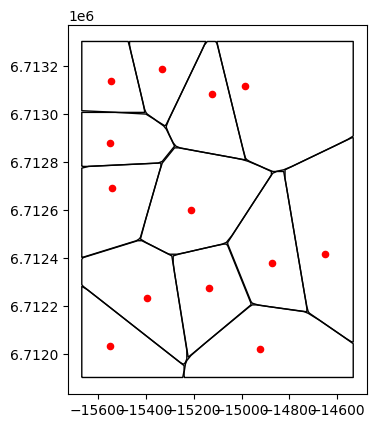

In [21]:
ax = voronoi.plot(edgecolor='black', facecolor='none')
pumps.plot(ax=ax, color='red', markersize=20)
plt.show()

count the number of deaths in each Voronoi cell

In [22]:
def count_deaths(voronoi, points):
    joined = gpd.sjoin(points, voronoi, predicate='within')
    voronoi['nb_of_deaths'] = joined.groupby('index_right').size()
    voronoi["nb_of_deaths"] = voronoi["nb_of_deaths"].fillna(0)
    return voronoi

bar chart showing the number of deaths in the Voronoi cells for each pump

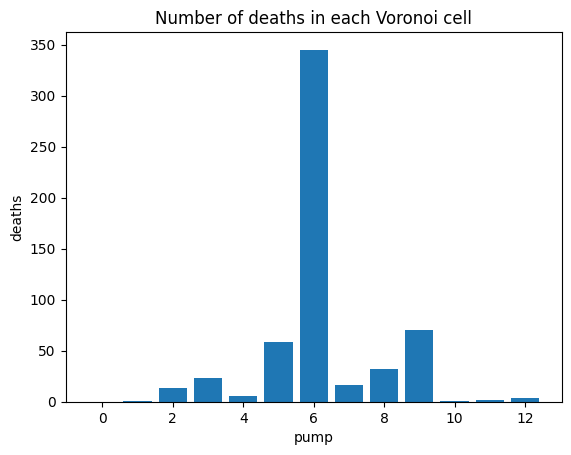

In [23]:
voronoi_deaths = count_deaths(voronoi, deaths)

plt.bar(voronoi_deaths.index, voronoi_deaths['nb_of_deaths'])
plt.xlabel('pump')
plt.ylabel('deaths')
plt.title("Number of deaths in each Voronoi cell")
plt.show()

note : since the function approximates the Voronoi cells, there are gaps between them. As a result, some deaths coordinates do not fall within a cell.
I could use bisectors or a grid with more points to solve the problem, but that would increase the algorithm complexity. Therefore I choose not to do so, in order to keep the computation time under 1 min.

This is not the most efficient algorithm, but I did not fully understood from the question whether we could use pre-implemented Voronoi algorithms or not.

In [24]:
print(f'Number of deaths outside the cells : {len(deaths) - sum(voronoi['nb_of_deaths'])}')

Number of deaths outside the cells : 6.0


source of the infection

In [25]:
voronoi_deaths['pumps'][voronoi_deaths['nb_of_deaths'] == max(voronoi_deaths['nb_of_deaths'])]

6    POINT (-15210.952 6712598.040)
Name: pumps, dtype: geometry

## Exercise 6

Create a death density map using 2D Kernel Density Estimation. Display the density and its contours on the map along with the pumps. What is the density value at each of the pumps? Pinpoint the possible source of the infection.

*Use the projected Cartesian coordinate system for this exercise.* 

cartesian coordinates : epsg = 3857, pseudo mercator

In [26]:
deaths = deaths.to_crs('epsg:3857')
pumps = pumps.to_crs('epsg:3857')

2D Kernel Density Estimation

Text(0.5, 1.0, '2D Kernel Density Estimation')

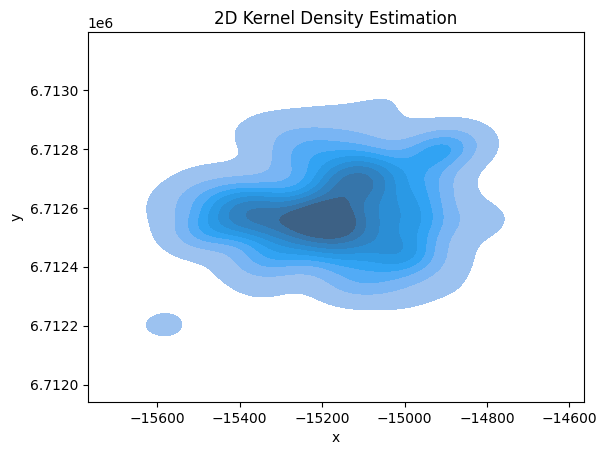

In [27]:
x_deaths = deaths.geometry.x
y_deaths = deaths.geometry.y

fig, ax = plt.subplots()
kde = sns.kdeplot(
    x=x_deaths,
    y=y_deaths,
    fill = True,
    ax = ax
)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('2D Kernel Density Estimation')

extract the outlines

In [28]:
polygons = []

for collection in ax.collections:
    for path in collection.get_paths():
        vertices = path.vertices
        polygons.append(Polygon(vertices))

geodf to store the outlines of the density estimation

In [29]:
contours = gpd.GeoDataFrame(
    geometry=polygons,
    crs=deaths.crs
)

project the data to WSG84 coordinates to put them on a folium map

In [30]:
deaths = deaths.to_crs('epsg:4326')
pumps = pumps.to_crs('epsg:4326')
contours = contours.to_crs('epsg:4326')

density map of deaths

In [31]:
deaths_map = folium.Map(location=[pumps.geometry.y.mean(), pumps.geometry.x.mean()], zoom_start= 16)

folium.GeoJson(
    contours,
    style_function=lambda x: {
        'color' : 'red'
    }
).add_to(deaths_map)

add pumps

In [32]:
for i, pump in pumps.iterrows():
    coord = [pump.geometry.y, pump.geometry.x]
    folium.CircleMarker(
        location= coord,
        radius = 2,
        color = 'blue',
        fill = True
    ).add_to(deaths_map)

deaths_map

pump density

In [33]:
kde = gaussian_kde(deaths[['X', 'Y']].to_numpy().T)
kde_pumps = kde(pumps[['X', 'Y']].to_numpy().T)
pumps['density'] = kde_pumps

pumps.sort_values('density')

,OBJECTID,X,Y,geometry,longitude,latitude,density
0,1,8.651201,17.891600,POINT (-0.13962 51.51630),-0.139621,51.516303,4.043602e-08
1,2,10.984780,18.517851,POINT (-0.13773 51.51658),-0.137734,51.516582,1.207836e-06
10,11,18.914391,9.737819,POINT (-0.13161 51.51228),-0.131612,51.512285,2.787963e-06
2,3,13.378190,17.394541,POINT (-0.13585 51.51602),-0.135846,51.516019,6.755756e-05
12,13,8.999440,5.101023,POINT (-0.13968 51.51015),-0.139680,51.510149,6.827315e-05
11,12,16.005110,5.046838,POINT (-0.13407 51.51006),-0.134067,51.510056,1.125097e-04
7,8,10.660970,7.428647,POINT (-0.13829 51.51125),-0.138287,51.511252,2.106492e-04
3,4,14.879830,17.809919,POINT (-0.13463 51.51620),-0.134632,51.516205,3.914976e-04
4,5,8.694768,14.905470,POINT (-0.13966 51.51487),-0.139665,51.514867,6.711484e-04
8,9,13.521460,7.958250,POINT (-0.13598 51.51148),-0.135981,51.511480,2.508894e-03


pump with the highest density value, source of the epidemy

In [34]:
pumps[pumps['density'] == max(pumps['density'])]

,OBJECTID,X,Y,geometry,longitude,latitude,density
6,7,12.57136,11.72717,POINT (-0.13664 51.51330),-0.136642,51.513302,0.048133


## Exercise 7

Create a GeoJSON object from the Voronoi cells, put the cells on the map, colored according to the number of deaths (like on a heatmap). Display the results in the notebook.

*[GeoJSON](http://geojson.org/) is a common format that is used in web applications. It is basically a simple key-value dictionary with a predefined structure for storing geographic information. Once loaded into Python, it behaves like a normal Python dictionary, thus creating or modifying it is quite straightforward. When reading or writing to a file, the `json` module is handy. The advice is to write a function that converts a list of coordinates from a polygon into a GeoJSON feature, then add it to your GeoJSON structure.*

map

In [35]:
center = [pumps.geometry.y.mean(), pumps.geometry.x.mean()]
voronoi_map = folium.Map(location=center, zoom_start=15)

define color scale according to the number of deaths

In [36]:
min_deaths = voronoi['nb_of_deaths'].min()
max_deaths = voronoi['nb_of_deaths'].max()

norm = colors.Normalize(vmin=min_deaths, vmax=max_deaths)
cmap = cm.OrRd

def color_scale(n):
    col = cmap(norm(n))
    return colors.to_hex(col)

define the style function to use the color scale on the folium map

In [37]:
def style_fuction(feature):
    n = feature['properties']['nb_of_deaths']
    return {'fillColor' : color_scale(n),
            'color' : 'white',
            'weight' : 1,
            'fillOpacity' : 0.7}

add Voronoi cells on the map, colored according to the numer of deaths

In [38]:
folium.GeoJson(
    voronoi[['polygon', 'nb_of_deaths']],
    style_function=style_fuction
).add_to(voronoi_map)

#folium.GeoJson(voronoi['pumps']).add_to(voronoi_map)
voronoi_map

## Exercise 8
(optional)
Download the street network of the area of the deaths from OpenStreetMap using its [map API](https://wiki.openstreetmap.org/wiki/API_v0.6#Retrieving_map_data_by_bounding_box:_GET_.2Fapi.2F0.6.2Fmap). Use street segments given back by the API as edges of a street graph. Develop a method based on the cholera dataset to classify these edges into three categories:
* existed at the time of John Snow
* did not exist at the time of John Snow
* cannot decide

*You'll get the id of each node and way that falls within a bounding box with the GET method of the map API. Use the ids to retrieve the shapes with the help of the ways API.*

*The results will be in XML format. Find a good [XML parser](https://docs.python.org/2/library/xml.etree.elementtree.html#module-xml.etree.ElementTree) to navigate the structures.*

## Exercise 9
(optional)

Plot the streets on the map along with the pumps and the deaths colored by the results of the classification.